Васаулюа Брюнотт Тази

## Задача 4

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
custom_colors = ["#FF6F61", "#FFA500", "#DAA520", "#17CEEB", "#32CD32", "#FF00FF", "#DC143C"]
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OutputCodeClassifier
from sklearn.multiclass import OneVsOneClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import cross_validate
from sklearn.multioutput import MultiOutputRegressor, RegressorChain
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge

## 1. Multiclass

Датасет из [Kaggle : Iris species](https://www.kaggle.com/datasets/uciml/iris?resource=download)

### Описание

- Id
- SepalLengthCm
- SepalWidthCm
- PetalLengthCm
- PetalWidthCm
- Species

In [52]:
data = pd.read_csv(r"data\iris\Iris.csv")
data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


# EDA

array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>]], dtype=object)

<Figure size 1900x1900 with 0 Axes>

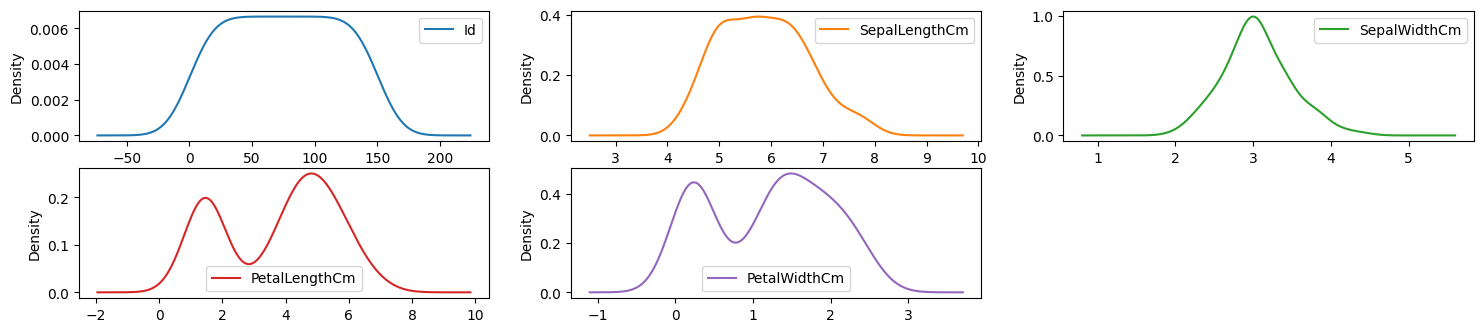

In [53]:
plt.figure(figsize=(19, 19))
data.plot(kind='density', subplots=True, layout=(9,3), sharex=False, sharey=False, figsize=(18, 18))

In [54]:
# @title Class vs Area

# from matplotlib import pyplot as plt
# import seaborn as sns
# figsize = (12, 1.2 * len(data['Species'].unique()))
# plt.figure(figsize=figsize)
# sns.violinplot(data, x='legs', y='Species', inner='box', palette='Dark2')
# sns.despine(top=True, right=True, bottom=True, left=True)

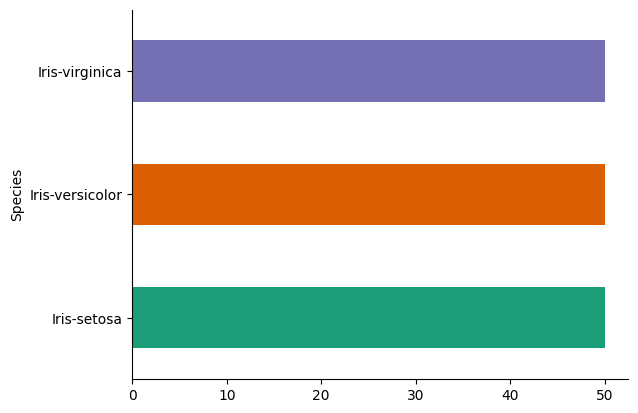

In [55]:
# @title Class

from matplotlib import pyplot as plt
import seaborn as sns
data.groupby('Species').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [56]:
# @title Perimeter

# from matplotlib import pyplot as plt
# data['Perimeter'].plot(kind='line', figsize=(8, 4), title='Perimeter')
# plt.gca().spines[['top', 'right']].set_visible(False)

In [57]:
data.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


Нет пропущенных данных

In [59]:
set(data["Species"])

{'Iris-setosa', 'Iris-versicolor', 'Iris-virginica'}

In [60]:
data.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [61]:
# sns.countplot(x="", data=data, palette=custom_colors)

In [62]:
# sns.distplot(data['Area'])

In [63]:
data.groupby('Species').mean()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,,
Iris-setosa,25.5,5.006,3.418,1.464,0.244
Iris-versicolor,75.5,5.936,2.770,4.260,1.326
Iris-virginica,125.5,6.588,2.974,5.552,2.026


### Преобразуем данные

In [64]:
# from sklearn.preprocessing import LabelEncoder

# # Create a LabelEncoder
# le = LabelEncoder()

# # Fit the LabelEncoder to the animal_name column
# le.fit(data['animal_name'])

# # Transform the animal_name column to numerical values
# data['animal_name'] = le.transform(data['animal_name'])

# # Print out the legend
# print("Legend:")
# for i, label in enumerate(le.classes_):
#     print(f"{i}: {label}")

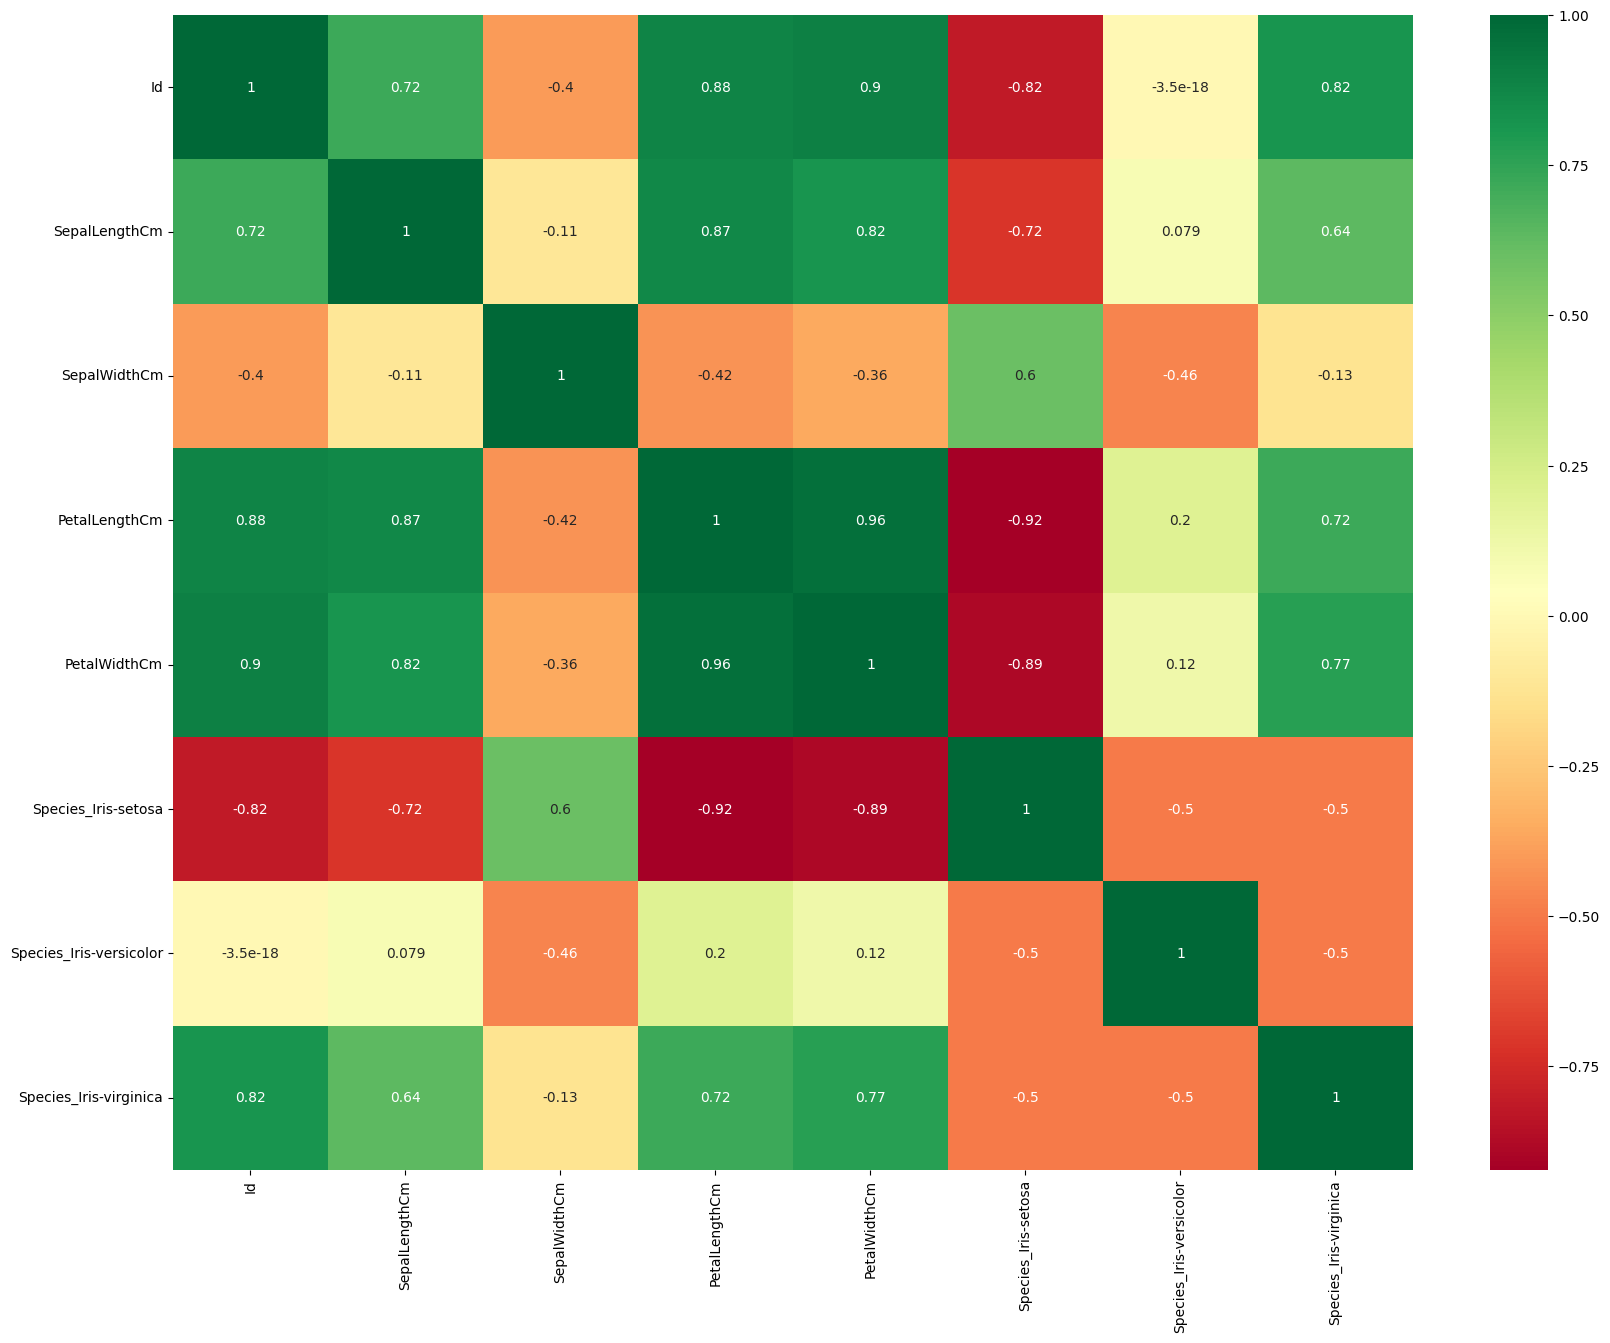

In [65]:
dum_data = pd.get_dummies(data, columns=['Species'])
sns.heatmap(dum_data.corr(), annot=True, cmap='RdYlGn')
fig = plt.gcf()
fig.set_size_inches(20, 15)
plt.show()

In [66]:
#data

### Вывод по EDA

###   Обучим модели.

In [67]:
X = data.drop('Species' , axis='columns')
y = data['Species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=37)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [68]:
param_grid = {'C': [1E-3, 1E-1, 1, 1E+1, 1E+3]}

# searcher = GridSearchCV(LogisticRegression(random_state=37), param_grid=param_grid, cv=5, scoring="roc_auc_ovr", error_score="raise")
searcher = GridSearchCV(LogisticRegression(random_state=37, multi_class='multinomial', solver='lbfgs'), param_grid=param_grid, cv=5, scoring="roc_auc_ovr", error_score="raise")
searcher = searcher.fit(X_train_scaled, y_train)

best_logreg_params = searcher.best_params_
print("Best params =", best_logreg_params)

Best params = {'C': 0.1}


In [69]:
param_grid = {"kernel": ["linear", "rbf"],
              "C": [0.1, 0.25, 0.5, 0.75, 1],
              "gamma": ["scale", "auto", 1E-3, 1E-1, 1]}

searcher = GridSearchCV(SVC(random_state=37, probability=True), param_grid=param_grid, cv=5)
searcher = searcher.fit(X_train_scaled, y_train)
best_svc_params = searcher.best_params_
print("Best params: ", best_svc_params)

Best params:  {'C': 0.25, 'gamma': 'scale', 'kernel': 'linear'}


In [70]:

param_grid = [{"n_neighbors": [1, 3, 5, 7, 9, 11, 13, 15, 17, 19],
               "weights": ['distance', 'uniform']}]

searcher = GridSearchCV(KNeighborsClassifier(), param_grid=param_grid, cv=5, scoring="roc_auc_ovr", error_score="raise")
searcher = searcher.fit(X_train_scaled, y_train)
best_knn_params = searcher.best_params_
print("Best params =", str(best_knn_params))

Best params = {'n_neighbors': 5, 'weights': 'distance'}


In [71]:
param_grid = [{"var_smoothing": np.logspace(0, -10, num=100)}]

searcher = GridSearchCV(GaussianNB(), param_grid=param_grid, cv=5, scoring="roc_auc_ovr", error_score="raise")
searcher = searcher.fit(X_train_scaled, y_train)
best_gnb_params = searcher.best_params_
print("Best params =", str(best_gnb_params))

Best params = {'var_smoothing': np.float64(0.12328467394420663)}


In [ ]:

param_grid = [{"criterion": ["gini", "entropy", "log_loss"],
               "splitter": ["best", "random"],
               "max_depth": [10, 20, 30],
               "min_samples_split": [2, 5, 10],
               "min_samples_leaf": [2, 5, 10],
               "max_features": [2, 5, 10]}]

searcher = GridSearchCV(DecisionTreeClassifier(random_state=19), param_grid=param_grid, cv=5, scoring="roc_auc_ovr", error_score="raise")
searcher = searcher.fit(X_train_scaled, y_train)
best_dt_params = searcher.best_params_
print("Best params =", str(best_dt_params))

In [ ]:

def measure_fit_time(model, X, y):
    return cross_validate(model, X, y, cv=5)["fit_time"].mean()

accuracies = {}
times = {}

## OneVsRest

In [ ]:
ovr_logreg = OneVsRestClassifier(LogisticRegression(**best_logreg_params, random_state=37)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, ovr_logreg.predict(X_test_scaled))
fit_time = measure_fit_time(ovr_logreg, X_train_scaled, y_train)

accuracies["OVR_Logreg"] = accuracy
times["OVR_Logreg"] = fit_time

print(f"OVR_Logreg accuracy {accuracy}")
print(f"OVR_Logreg time {fit_time}")

OVR_Logreg accuracy 1.0
OVR_Logreg time 0.055236291885375974


In [ ]:

ovr_svm = OneVsRestClassifier(SVC(**best_svc_params, random_state=37, probability=True)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, ovr_svm.predict(X_test_scaled))
fit_time = measure_fit_time(ovr_svm, X_train_scaled, y_train)

accuracies["OVR_SVM"] = accuracy
times["OVR_SVM"] = fit_time

print(f"OVR_SVM accuracy {accuracy}")
print(f"OVR_SVM time {fit_time}")

OVR_SVM accuracy 1.0
OVR_SVM time 0.0493586540222168


In [ ]:

ovr_knn = OneVsRestClassifier(KNeighborsClassifier(**best_knn_params)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, ovr_knn.predict(X_test_scaled))
fit_time = measure_fit_time(ovr_knn, X_train_scaled, y_train)

accuracies["OVR_KNN"] = accuracy
times["OVR_KNN"] = fit_time

print(f"OVR_KNN accuracy {accuracy}")
print(f"OVR_KNN time {fit_time}")

OVR_KNN accuracy 1.0
OVR_KNN time 0.02566242218017578


In [ ]:

ovr_nb = OneVsRestClassifier(GaussianNB(**best_gnb_params)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, ovr_nb.predict(X_test_scaled))
fit_time = measure_fit_time(ovr_nb, X_train_scaled, y_train)

accuracies["OVR_GNB"] = accuracy
times["OVR_GNB"] = fit_time

print(f"OVR_GNB accuracy {accuracy}")
print(f"OVR_GNB time {fit_time}")

OVR_GNB accuracy 1.0
OVR_GNB time 0.028156185150146486


In [ ]:
ovr_dt = OneVsRestClassifier(DecisionTreeClassifier(**best_dt_params, random_state=37)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, ovr_dt.predict(X_test_scaled))
fit_time = measure_fit_time(ovr_dt, X_train_scaled, y_train)

accuracies["OVR_DT"] = accuracy
times["OVR_DT"] = fit_time

print(f"OVR_DT accuracy {accuracy}")
print(f"OVR_DT time {fit_time}")

OVR_DT accuracy 1.0
OVR_DT time 0.031076860427856446


## OneVsOne

In [ ]:

ovo_logreg = OneVsOneClassifier(LogisticRegression(**best_logreg_params, random_state=37)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, ovo_logreg.predict(X_test_scaled))
fit_time = measure_fit_time(ovo_logreg, X_train_scaled, y_train)

accuracies["OVO_Logreg"] = accuracy
times["OVO_Logreg"] = fit_time

print(f"OVO_Logreg accuracy {accuracy}")
print(f"OVO_Logreg time {fit_time}")

OVO_Logreg accuracy 1.0
OVO_Logreg time 0.05896263122558594


In [ ]:
ovo_svm = OneVsOneClassifier(SVC(**best_svc_params, random_state=37, probability=True)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, ovo_svm.predict(X_test_scaled))
fit_time = measure_fit_time(ovo_svm, X_train_scaled, y_train)

accuracies["OVO_SVM"] = accuracy
times["OVO_SVM"] = fit_time

print(f"OVO_SVM accuracy {accuracy}")
print(f"OVO_SVM time {fit_time}")

OVO_SVM accuracy 1.0
OVO_SVM time 0.02830643653869629


In [ ]:

ovo_knn = OneVsOneClassifier(KNeighborsClassifier(**best_knn_params)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, ovo_knn.predict(X_test_scaled))
fit_time = measure_fit_time(ovo_knn, X_train_scaled, y_train)

accuracies["OVO_KNN"] = accuracy
times["OVO_KNN"] = fit_time

print(f"OVO_KNN accuracy {accuracy}")
print(f"OVO_KNN time {fit_time}")

OVO_KNN accuracy 1.0
OVO_KNN time 0.01920347213745117


In [ ]:

ovo_nb = OneVsOneClassifier(GaussianNB(**best_gnb_params)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, ovo_nb.predict(X_test_scaled))
fit_time = measure_fit_time(ovo_nb, X_train_scaled, y_train)

accuracies["OVO_GNB"] = accuracy
times["OVO_GNB"] = fit_time

print(f"OVO_GNB accuracy {accuracy}")
print(f"OVO_GNB time {fit_time}")

OVO_GNB accuracy 1.0
OVO_GNB time 0.021754884719848634


In [ ]:
ovo_dt = OneVsOneClassifier(DecisionTreeClassifier(**best_dt_params, random_state=37)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, ovo_dt.predict(X_test_scaled))
fit_time = measure_fit_time(ovo_dt, X_train_scaled, y_train)

accuracies["OVO_DT"] = accuracy
times["OVO_DT"] = fit_time

print(f"OVO_DT accuracy {accuracy}")
print(f"OVO_DT time {fit_time}")

OVO_DT accuracy 1.0
OVO_DT time 0.03559417724609375



## OutputCode

In [ ]:

oc_logreg = OutputCodeClassifier(LogisticRegression(**best_logreg_params, random_state=37)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, oc_logreg.predict(X_test_scaled))
fit_time = measure_fit_time(oc_logreg, X_train_scaled, y_train)

accuracies["OС_Logreg"] = accuracy
times["OС_Logreg"] = fit_time

print(f"OС_Logreg accuracy {accuracy}")
print(f"OС_Logreg time {fit_time}")

OС_Logreg accuracy 0.5666666666666667
OС_Logreg time 0.04643349647521973


In [ ]:
oc_svm = OutputCodeClassifier(SVC(**best_svc_params, random_state=37, probability=True)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, oc_svm.predict(X_test_scaled))
fit_time = measure_fit_time(oc_svm, X_train_scaled, y_train)

accuracies["OC_SVM"] = accuracy
times["OC_SVM"] = fit_time

print(f"OC_SVM accuracy {accuracy}")
print(f"OC_SVM time {fit_time}")

OC_SVM accuracy 1.0
OC_SVM time 0.03374423980712891


In [ ]:

oc_knn = OutputCodeClassifier(KNeighborsClassifier(**best_knn_params)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, oc_knn.predict(X_test_scaled))
fit_time = measure_fit_time(oc_knn, X_train_scaled, y_train)

accuracies["OC_KNN"] = accuracy
times["OC_KNN"] = fit_time

print(f"OC_KNN accuracy {accuracy}")
print(f"OC_KNN time {fit_time}")

OC_KNN accuracy 1.0
OC_KNN time 0.01867213249206543


In [ ]:
oc_nb = OutputCodeClassifier(GaussianNB(**best_gnb_params)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, oc_nb.predict(X_test_scaled))
fit_time = measure_fit_time(oc_nb, X_train_scaled, y_train)

accuracies["OC_GNB"] = accuracy
times["OC_GNB"] = fit_time

print(f"OC_GNB accuracy {accuracy}")
print(f"OC_GNB time {fit_time}")

OC_GNB accuracy 0.5666666666666667
OC_GNB time 0.020952129364013673


In [ ]:

oc_dt = OutputCodeClassifier(DecisionTreeClassifier(**best_dt_params, random_state=37)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, oc_dt.predict(X_test_scaled))
fit_time = measure_fit_time(oc_dt, X_train_scaled, y_train)

accuracies["OC_DT"] = accuracy
times["OC_DT"] = fit_time

print(f"OC_DT accuracy {accuracy}")
print(f"OC_DT time {fit_time}")

OC_DT accuracy 1.0
OC_DT time 0.02775259017944336


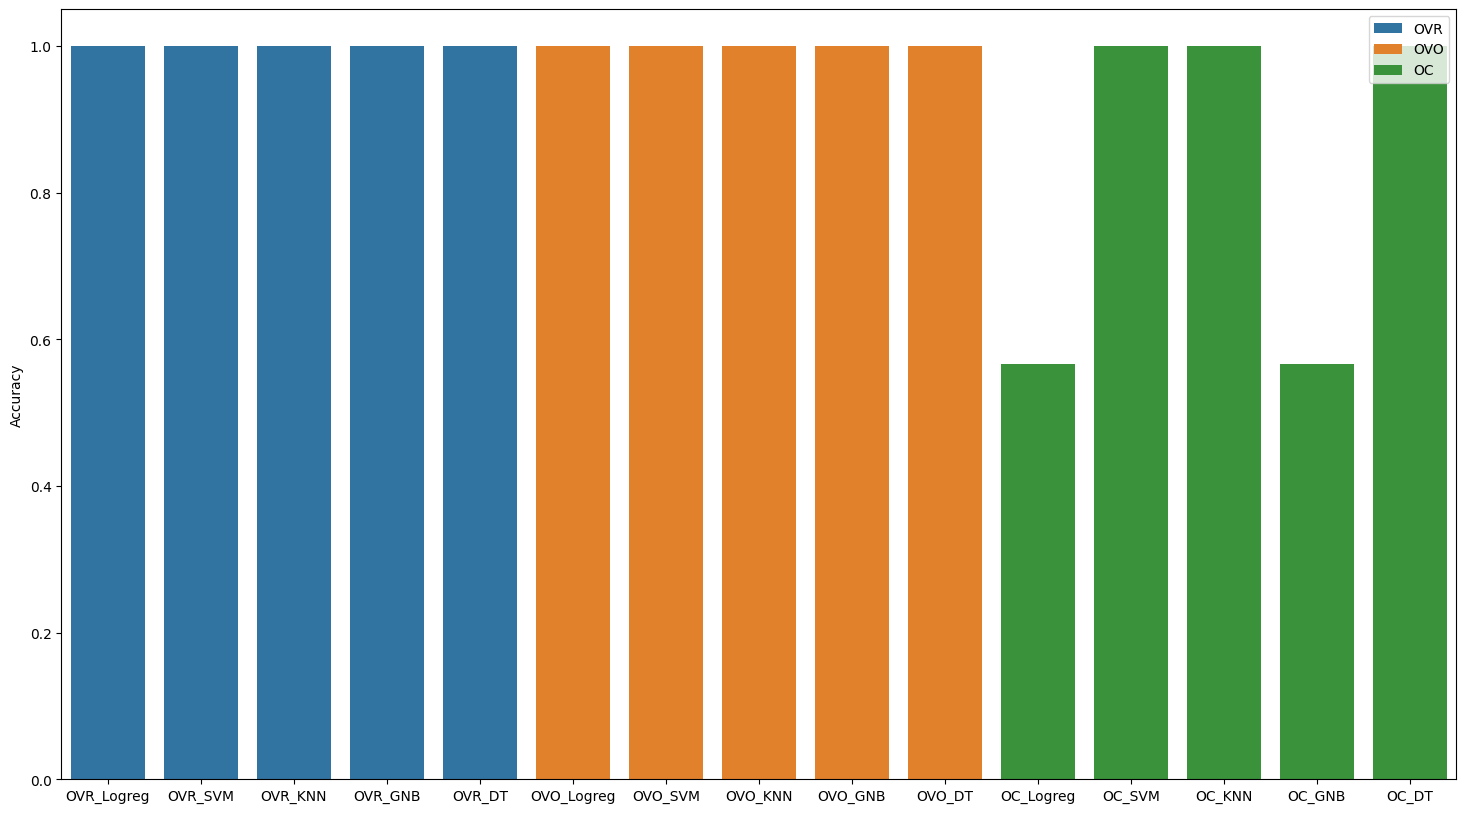

In [ ]:

plt.figure(figsize=(22, 10))
plt.ylabel("Accuracy")
colors = ['OVR']*5 + ['OVO']*5 + ['OC']*5
sns.barplot(y=list(accuracies.values()), x=list(accuracies.keys()), hue=colors)
plt.show()

['OVR_Logreg', 'OVR_SVM', 'OVR_KNN', 'OVR_GNB', 'OVR_DT', 'OVO_Logreg', 'OVO_SVM', 'OVO_KNN', 'OVO_GNB', 'OVO_DT', 'OС_Logreg', 'OC_SVM', 'OC_KNN', 'OC_GNB', 'OC_DT']


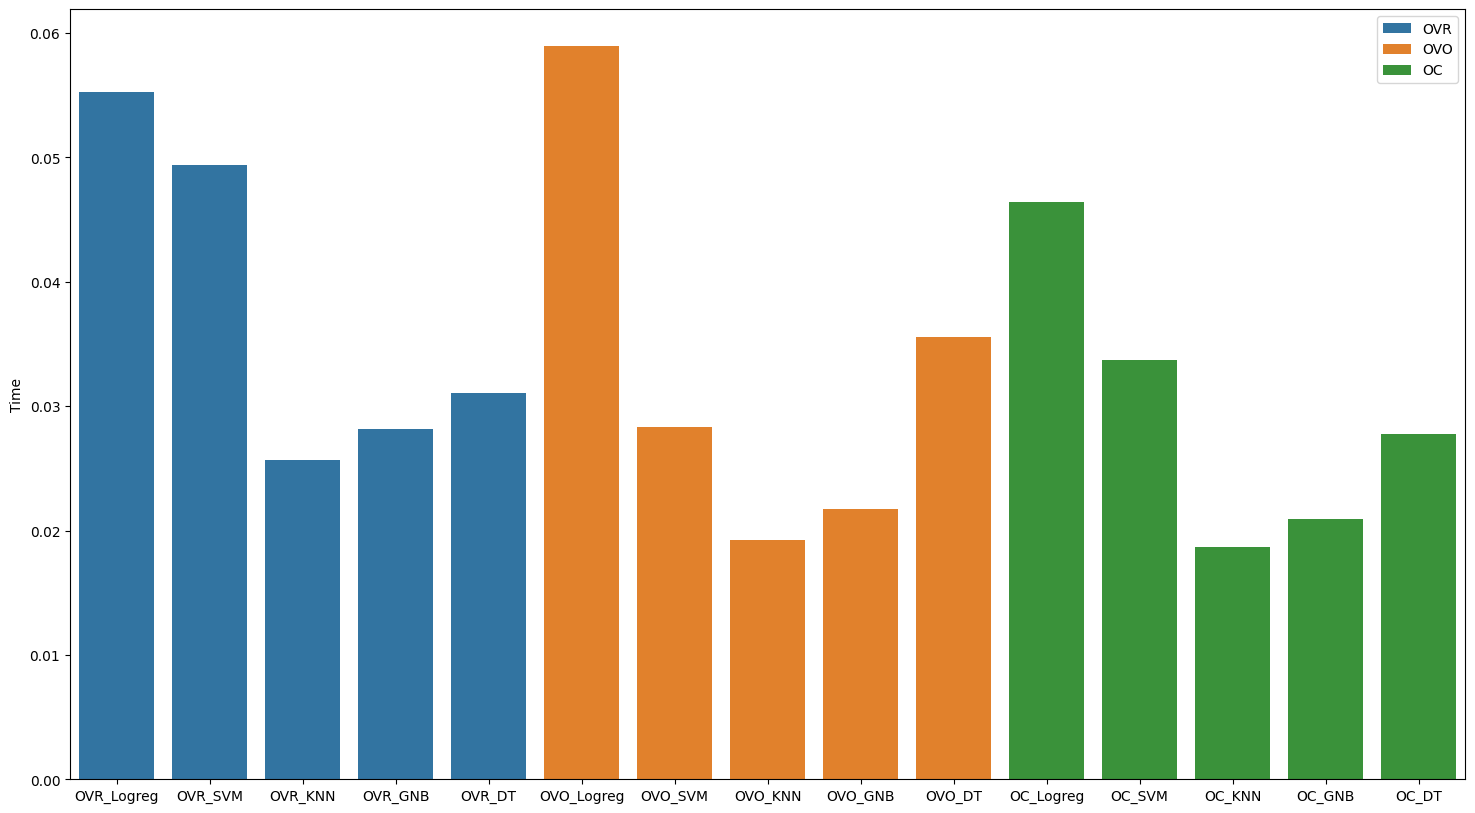

In [ ]:

plt.figure(figsize=(22, 10))
plt.ylabel("Time")
sns.barplot(y=list(times.values()), x=list(times.keys()), hue=colors)
plt.show()

## 2. Multilabel

In [ ]:
data2 = pd.read_csv(r"data\spb\cleaned_data.csv")
data2

,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,price_per_area
0,13000000.0,108.00,3,2.700000,16.0,51.000000,8,1,0,0,25.000000,1.150082,34,18863.000000,16028.000000,1.000000,482.000000,2.000000,755.0000,120370.370370
1,3350000.0,40.40,1,2.771499,11.0,18.600000,1,1,0,0,11.000000,2.000000,327,12817.000000,18603.000000,0.000000,490.804555,0.000000,517.9809,82920.792079
2,5196000.0,56.00,2,2.771499,5.0,34.300000,4,1,0,0,8.300000,0.000000,34,21741.000000,13933.000000,1.000000,90.000000,2.000000,574.0000,92785.714286
3,64900000.0,159.00,3,2.771499,14.0,34.457852,9,1,0,0,10.569807,0.000000,34,28098.000000,6800.000000,2.000000,84.000000,3.000000,234.0000,408176.100629
4,10000000.0,100.00,2,3.030000,14.0,32.000000,13,1,0,0,41.000000,1.150082,34,31856.000000,8098.000000,2.000000,112.000000,1.000000,48.0000,100000.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23694,9700000.0,133.81,3,3.700000,5.0,73.300000,3,1,0,0,13.830000,1.150082,34,24665.000000,4232.000000,1.000000,796.000000,3.000000,381.0000,72490.845228
23695,3100000.0,59.00,3,2.771499,5.0,38.000000,4,1,0,0,8.500000,1.150082,42,28793.672193,14191.277833,0.611408,490.804555,0.770255,517.9809,52542.372881
23696,2500000.0,56.70,2,2.771499,3.0,29.700000,1,1,0,0,10.569807,1.150082,361,28793.672193,14191.277833,0.611408,490.804555,0.770255,517.9809,44091.710758
23697,11475000.0,76.75,2,3.000000,17.0,34.457852,12,1,0,0,23.300000,2.000000,34,39140.000000,10364.000000,2.000000,173.000000,3.000000,196.0000,149511.400651


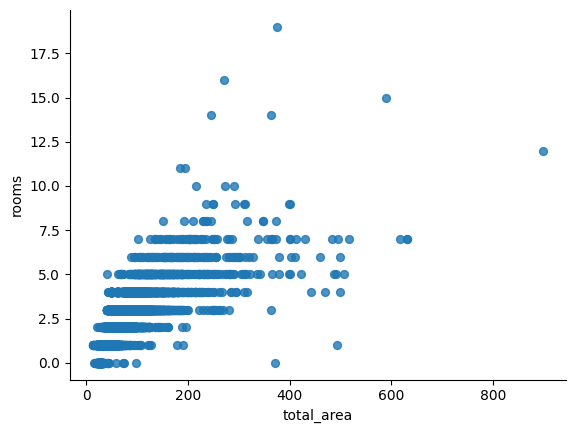

In [ ]:
# @title total_area vs rooms

from matplotlib import pyplot as plt
data2.plot(kind='scatter', x='total_area', y='rooms', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

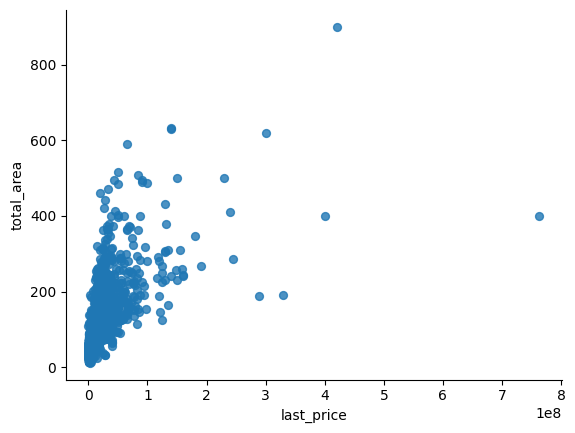

In [ ]:
# @title last_price vs total_area

from matplotlib import pyplot as plt
data2.plot(kind='scatter', x='last_price', y='total_area', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

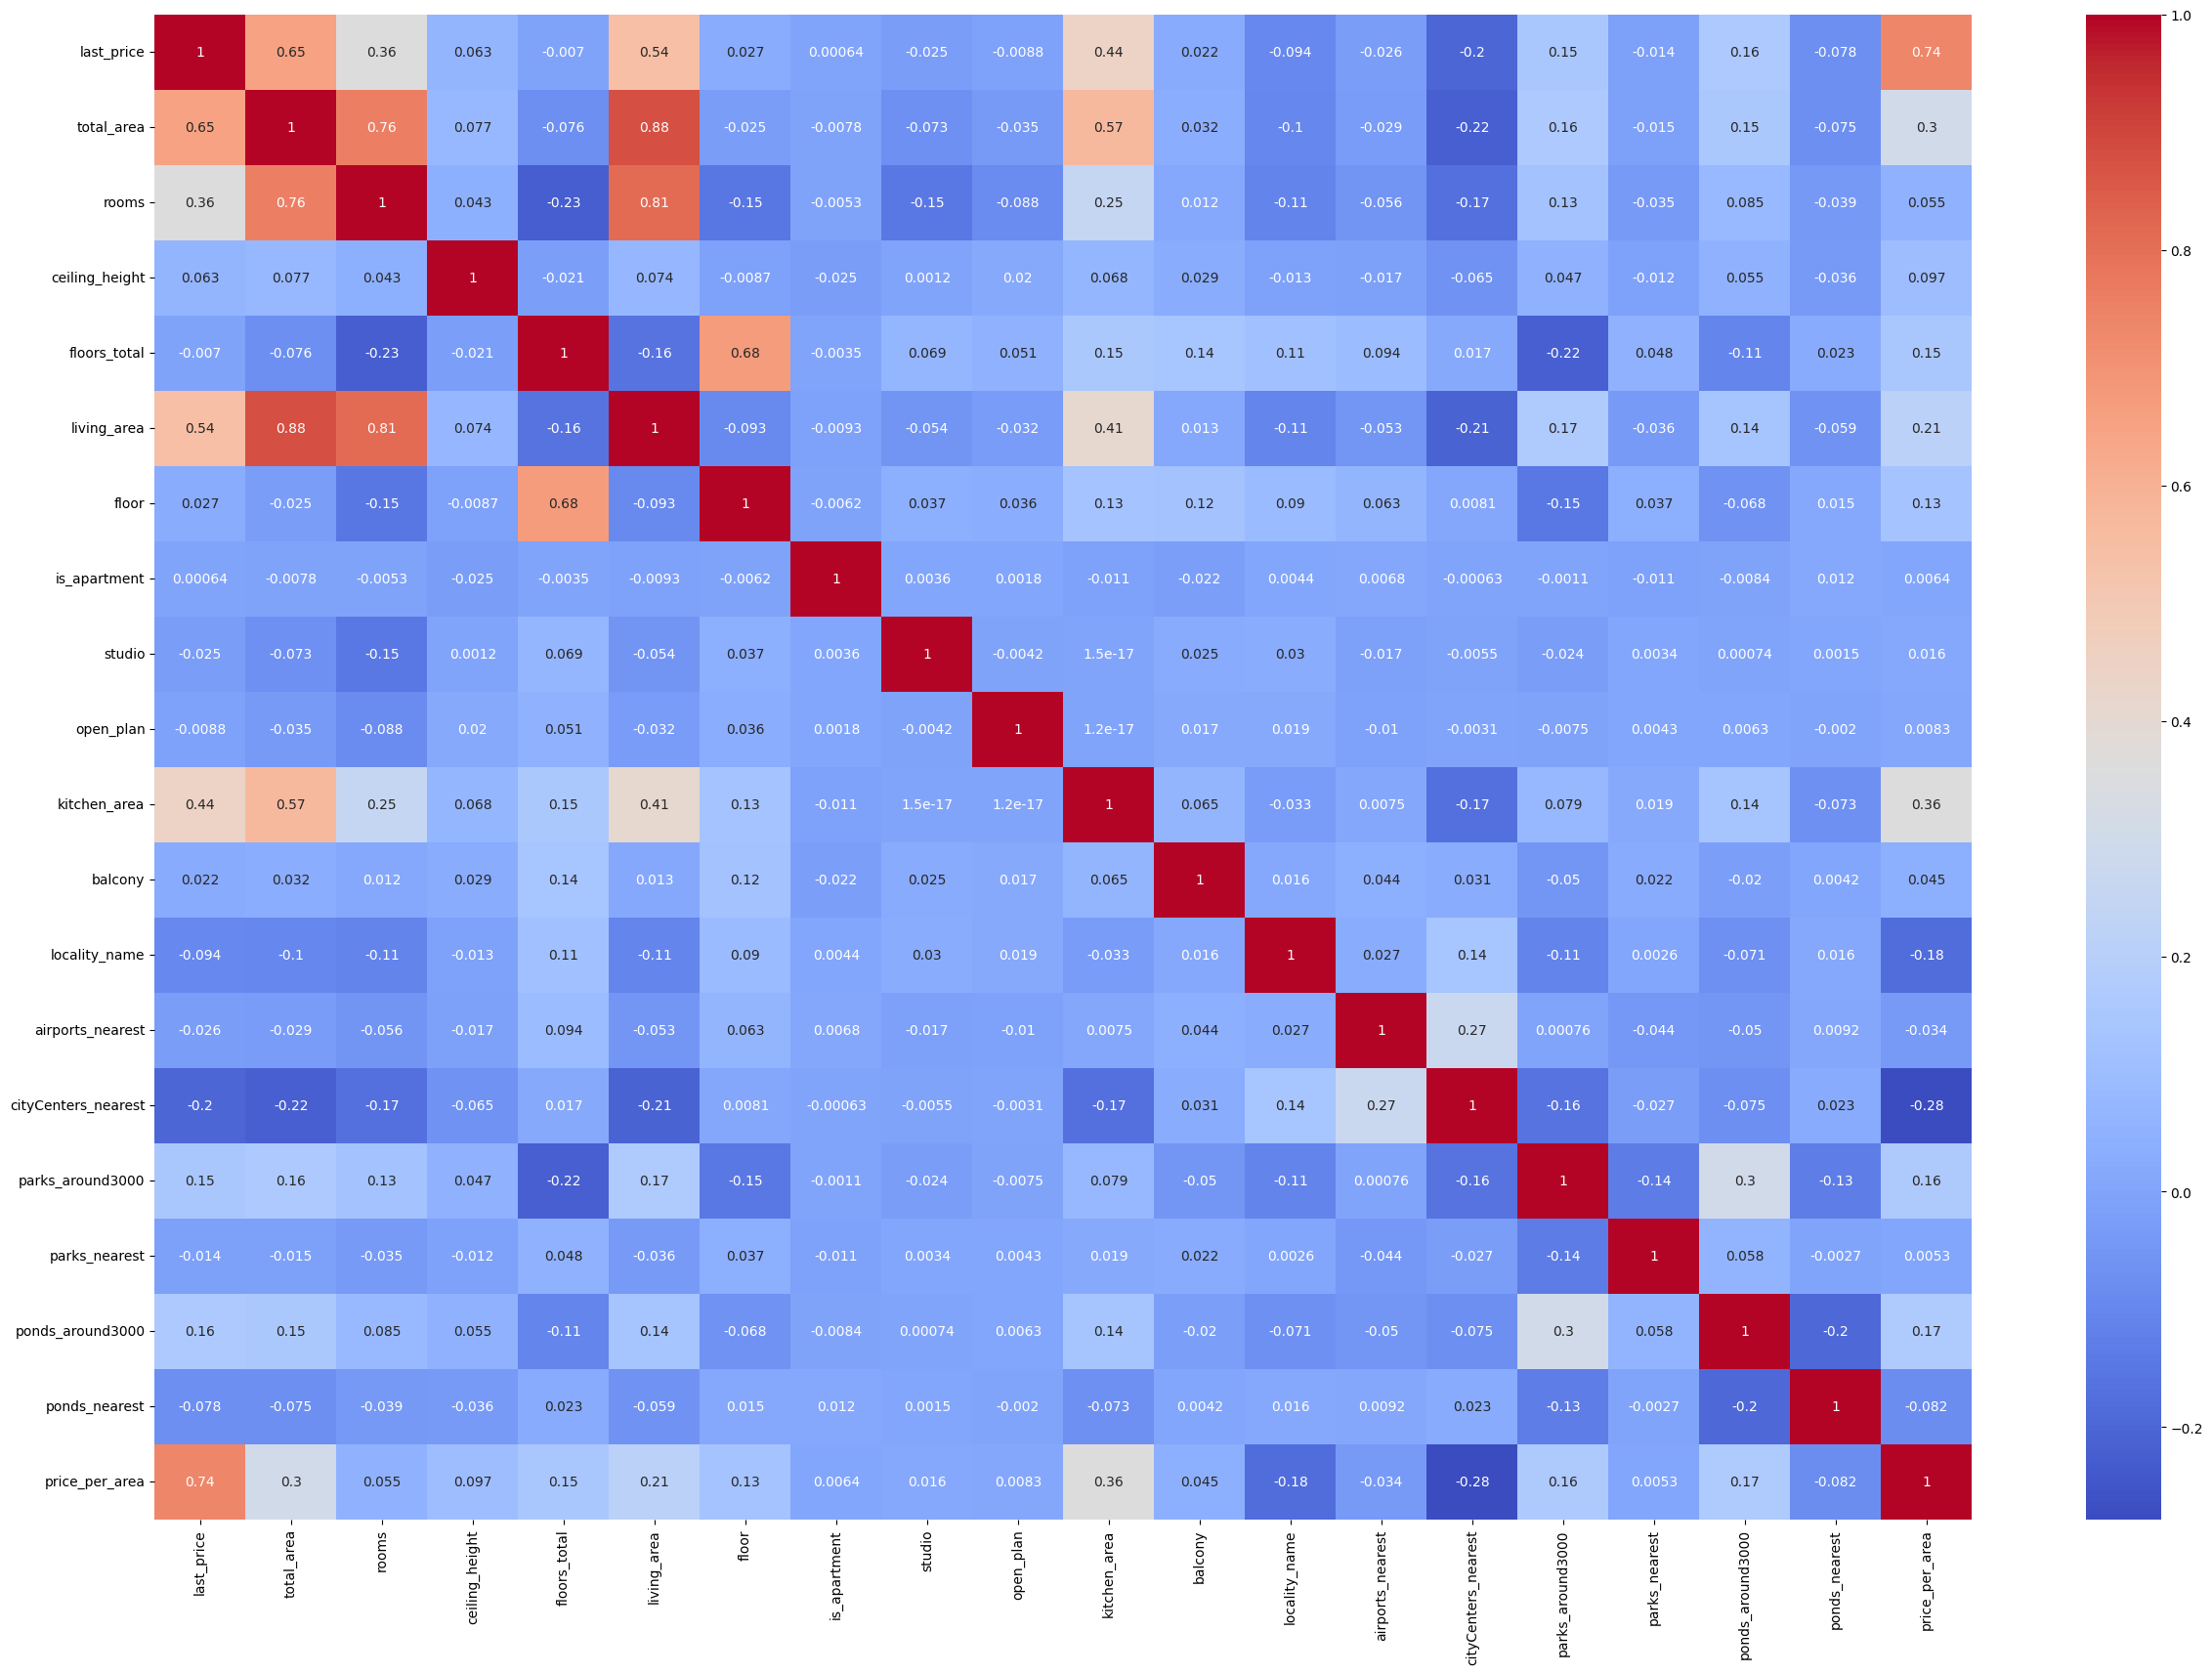

In [ ]:
corr_matrix = data2.corr()
plt.figure(figsize=(30, 20))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
y = data2[['balcony','parks_around3000','airports_nearest']]
X = data2.drop(['balcony','parks_around3000','airports_nearest'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=37)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

accuracies = {}
times = {}

In [ ]:

param_grid = {"alpha": np.logspace(-5, 3, 20)}

searcher = GridSearchCV(Ridge(), param_grid, scoring="r2", cv=5)
searcher.fit(X_train_scaled, y_train)

best_ridge_params = searcher.best_params_

In [ ]:

mor_ridge = MultiOutputRegressor(Ridge(**best_ridge_params))
mor_ridge.fit(X_train_scaled, y_train)
y_pred = mor_ridge.predict(X_test_scaled)
fit_time = measure_fit_time(mor_ridge, X_train_scaled, y_train)
r2 = r2_score(y_test, y_pred)
accuracies["MOR_Ridge"] = r2
times["MOR_Ridge"] = fit_time
print(f"MOR_Ridge R^2 {r2}")
print(f"MOR_Ridge time {fit_time}")

MOR_Ridge R^2 0.1098850574638303
MOR_Ridge time 0.1217848777770996


In [ ]:
rc_ridge = RegressorChain(Ridge(**best_ridge_params))
rc_ridge.fit(X_train_scaled, y_train)
y_pred = rc_ridge.predict(X_test_scaled)
fit_time = measure_fit_time(rc_ridge, X_train_scaled, y_train)
r2 = r2_score(y_test, y_pred)
accuracies["RC_Ridge"] = r2
times["RC_Ridge"] = fit_time
print(f"RC_Ridge R^2 {r2}")
print(f"RC_Ridge time {fit_time}")

RC_Ridge R^2 0.10988505746383033
RC_Ridge time 0.08875203132629395


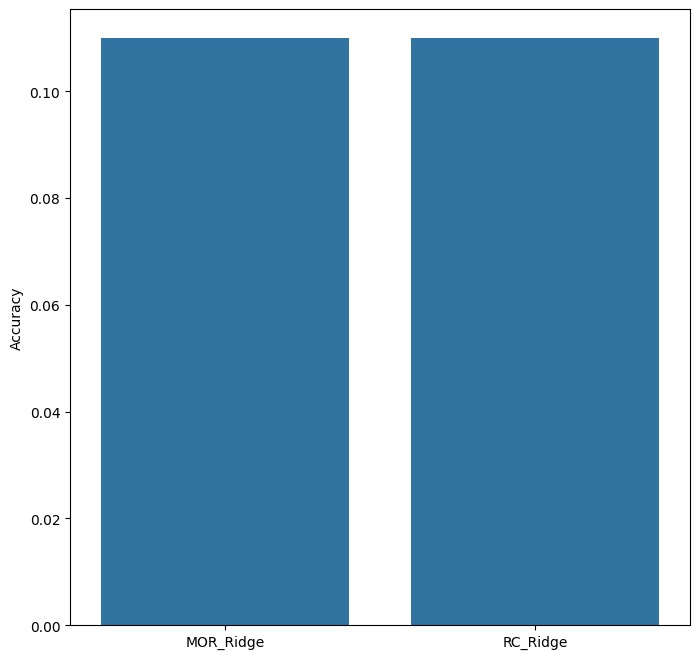

In [ ]:
plt.figure(figsize=(8, 8))
plt.ylabel("Accuracy")

sns.barplot(y=list(accuracies.values()), x=list(accuracies.keys()))
plt.show()

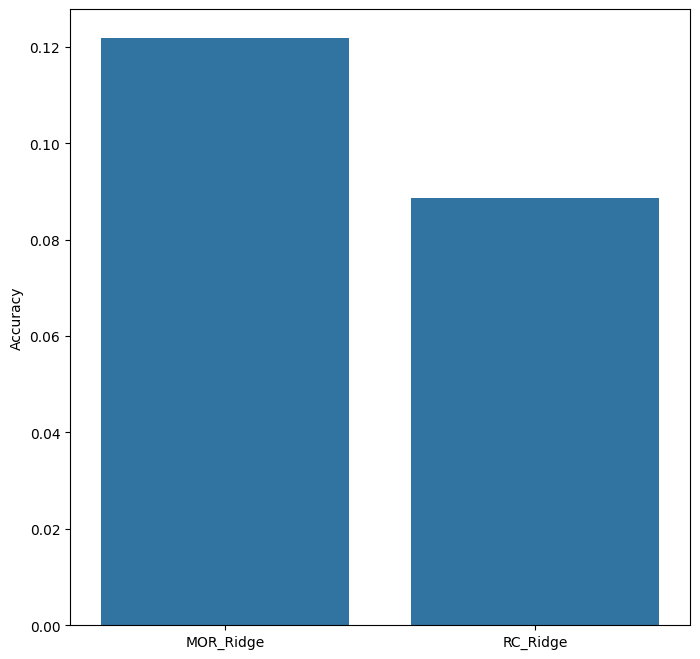

In [ ]:
plt.figure(figsize=(8, 8))
plt.ylabel("Accuracy")

sns.barplot(y=list(times.values()), x=list(times.keys()))
plt.show()